In [1]:
import pandas as pd
import matplotlib.pyplot as plt
rows = []
with open("pileheight_3param.dat", "r") as f:
    for line in f:
        parts = line.split()
        if len(parts) == 6:
            rows.append([float(x) for x in parts])

df = pd.DataFrame(rows, columns=[
    "mu", "mu_roll", "mu_twist", "pileH", "theta_deg", "ztot"
])

print(df.head())
print(df.shape)

    mu  mu_roll  mu_twist     pileH  theta_deg      ztot
0  0.1     0.00      0.00  7.699337  28.857291  5.138254
1  0.1     0.00      0.05  8.083253  30.399542  4.781566
2  0.1     0.00      0.10  7.749114  28.922851  4.795804
3  0.1     0.05      0.00  8.080742  29.882307  4.862495
4  0.1     0.05      0.05  7.886472  29.866740  4.754590
(39, 6)


In [2]:
#import pandas as pd
#import matplotlib.pyplot as plt

# load (adjust names if needed)
#df = pd.read_csv("pileheight_3param.dat", sep="\\s+")

#df.columns = ["mu", "mu_roll", "mu_twist", "pileH", "theta", "ztot"]

# pick one slice
twist_val = df["mu_twist"].unique()[0]
slice_df = df[df["mu_twist"] == twist_val]

pivot = slice_df.pivot(index="mu_roll", columns="mu", values="pileH")

plt.imshow(pivot, origin='lower', aspect='auto')
plt.colorbar(label="Pile Height")
plt.xlabel("mu (sliding)")
plt.ylabel("mu_roll")
plt.title(f"Pile Height (mu_twist={twist_val})")
plt.show()

ValueError: Index contains duplicate entries, cannot reshape

In [3]:
dups = (
    slice_df
    .groupby(["mu_roll", "mu"])
    .size()
    .reset_index(name="count")
)

print(dups[dups["count"] > 1])

   mu_roll   mu  count
0      0.0  0.1      3


In [4]:
print(slice_df[(slice_df["mu_roll"] == 0.0) & (slice_df["mu"] == 0.1)])

     mu  mu_roll  mu_twist     pileH  theta_deg      ztot
0   0.1      0.0       0.0  7.699337  28.857291  5.138254
36  0.1      0.0       0.0  7.699337  28.857291  5.138254
37  0.1      0.0       0.0  7.699337  28.857291  5.138254


In [5]:
df = df.drop_duplicates()

In [6]:
twist_val = df["mu_twist"].unique()[0]
slice_df = df[df["mu_twist"] == twist_val]

pivot = slice_df.pivot(
    index="mu_roll",
    columns="mu",
    values="pileH"
)

In [7]:
print(df.duplicated().sum())

0


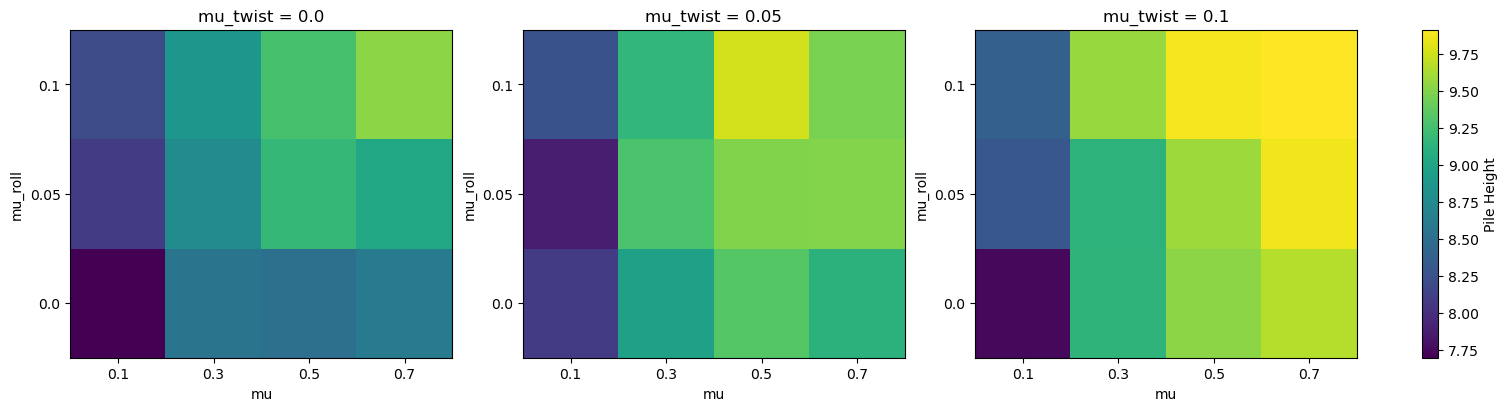

In [8]:


twist_vals = sorted(df["mu_twist"].unique())
fig, axes = plt.subplots(
    1, len(twist_vals),
    figsize=(5*len(twist_vals), 4),
    constrained_layout=True   # ✅ THIS FIXES IT
)
#fig, axes = plt.subplots(1, len(twist_vals), figsize=(5*len(twist_vals), 4))

# 👇 THIS FIXES YOUR ERROR
if len(twist_vals) == 1:
    axes = [axes]

vmin = df["pileH"].min()
vmax = df["pileH"].max()

for ax, twist_val in zip(axes, twist_vals):
    sub = df[df["mu_twist"] == twist_val]
    pivot = sub.pivot(index="mu_roll", columns="mu", values="pileH")

    im = ax.imshow(pivot, origin="lower", aspect="auto",
                   vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_xlabel("mu")
    ax.set_ylabel("mu_roll")
    ax.set_title(f"mu_twist = {twist_val}")

fig.colorbar(im, ax=axes, label="Pile Height")

#plt.tight_layout()
plt.show()

In [9]:
df.groupby("mu_twist")["pileH"].mean()


mu_twist
0.00    8.692498
0.05    9.027645
0.10    9.226563
Name: pileH, dtype: float64

In [10]:
import numpy as np

mu_t = np.array([0.00, 0.05, 0.10])
H = np.array([8.692498, 9.027645, 9.226563])

coef = np.polyfit(mu_t, H, 1)
print("Slope dH/d(mu_twist) =", coef[0])

Slope dH/d(mu_twist) = 5.340650000000044


In [11]:
#comparing slopes accross parameters
df.groupby("mu")["pileH"].mean()
df.groupby("mu_roll")["pileH"].mean()

mu_roll
0.00    8.748471
0.05    9.008408
0.10    9.189828
Name: pileH, dtype: float64

In [12]:
np.polyfit(mu_t, H, 2)


array([-27.2458  ,   8.06523 ,   8.692498])

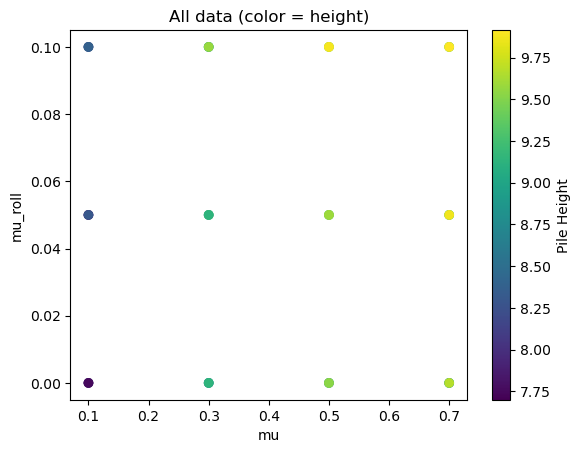

In [13]:
plt.scatter(df["mu"], df["mu_roll"], c=df["pileH"])
plt.colorbar(label="Pile Height")
plt.xlabel("mu")
plt.ylabel("mu_roll")
plt.title("All data (color = height)")
plt.show()

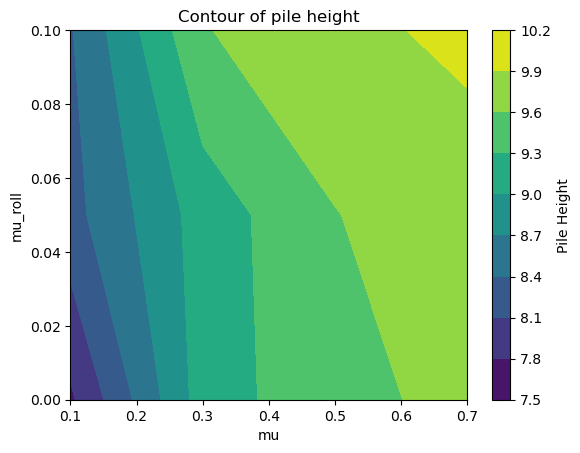

In [14]:
plt.contourf(pivot.columns, pivot.index, pivot.values)
plt.colorbar(label="Pile Height")
plt.xlabel("mu")
plt.ylabel("mu_roll")
plt.title("Contour of pile height")
plt.show()


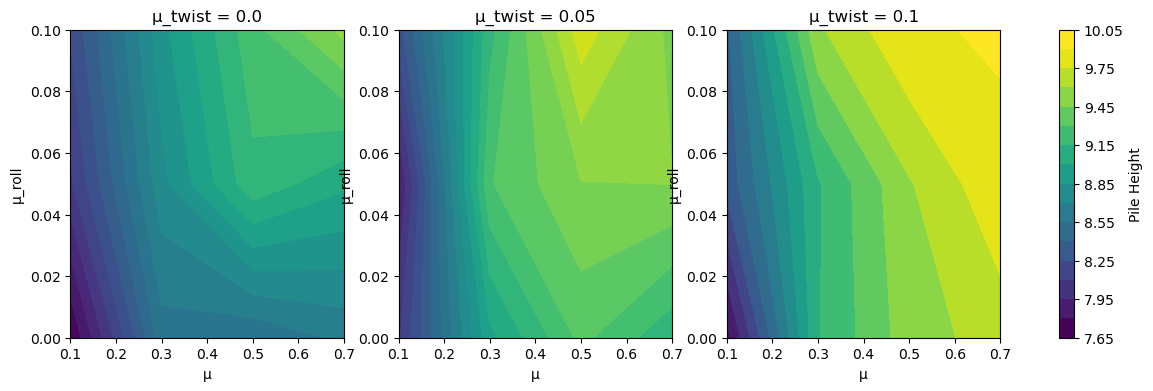

In [15]:
import matplotlib.pyplot as plt

twist_vals = sorted(df["mu_twist"].unique())

fig, axes = plt.subplots(1, len(twist_vals), figsize=(5*len(twist_vals), 4))

if len(twist_vals) == 1:
    axes = [axes]

vmin = df["pileH"].min()
vmax = df["pileH"].max()

for ax, twist_val in zip(axes, twist_vals):
    sub = df[df["mu_twist"] == twist_val]
    pivot = sub.pivot(index="mu_roll", columns="mu", values="pileH")

    X = pivot.columns.values
    Y = pivot.index.values
    Z = pivot.values

    contour = ax.contourf(X, Y, Z, levels=20, vmin=vmin, vmax=vmax)

    ax.set_title(f"μ_twist = {twist_val}")
    ax.set_xlabel("μ")
    ax.set_ylabel("μ_roll")

fig.colorbar(contour, ax=axes, label="Pile Height")
plt.show()

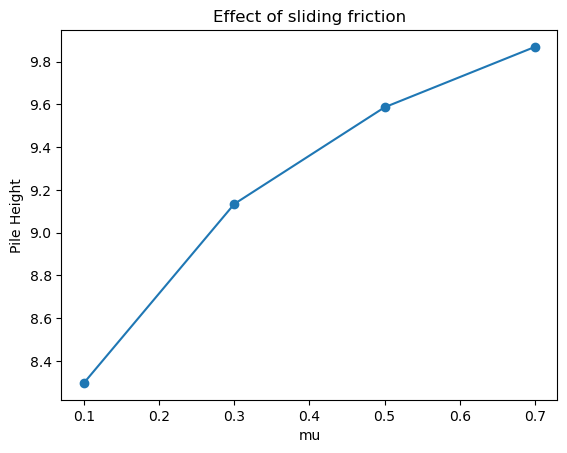

In [16]:
import numpy as np
import matplotlib.pyplot as plt

subset = df[
    (np.isclose(df["mu_roll"], 0.05)) &
    (np.isclose(df["mu_twist"], 0.1))
]

subset = subset.sort_values("mu")

plt.plot(subset["mu"], subset["pileH"], marker='o')
plt.xlabel("mu")
plt.ylabel("Pile Height")
plt.title("Effect of sliding friction")

plt.show()

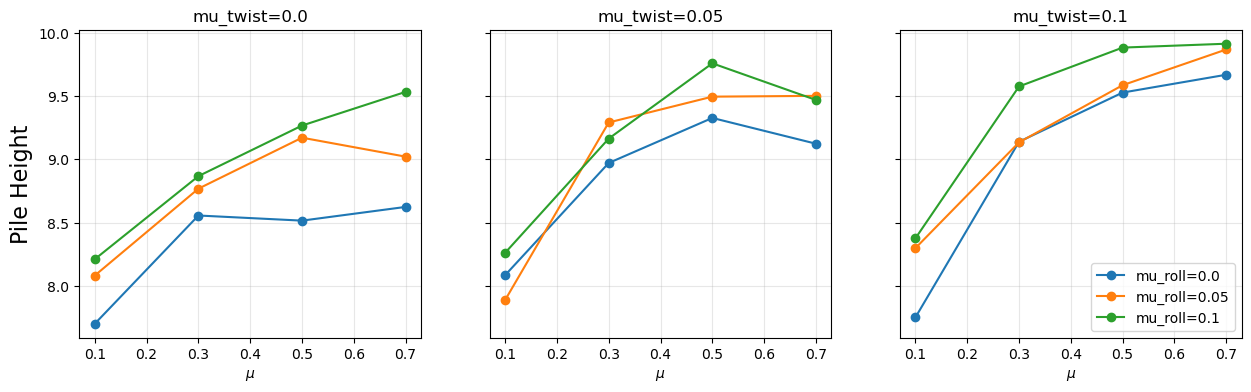

In [25]:
import numpy as np
import matplotlib.pyplot as plt

twist_vals = sorted(df["mu_twist"].unique())
roll_vals = sorted(df["mu_roll"].unique())

fig, axes = plt.subplots(1, len(twist_vals), figsize=(5 * len(twist_vals), 4), sharey=True)

if len(twist_vals) == 1:
    axes = [axes]

for ax, twist_val in zip(axes, twist_vals):
    for roll_val in roll_vals:
        subset = df[
            np.isclose(df["mu_twist"], twist_val) &
            np.isclose(df["mu_roll"], roll_val)
        ].sort_values("mu")

        if len(subset) < 2:
            continue

        ax.plot(subset["mu"], subset["pileH"], marker="o", label=f"mu_roll={roll_val}")

    ax.set_xlabel(r"$\mu$")
    ax.set_title(f"mu_twist={twist_val}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Pile Height", fontsize=16)
axes[-1].legend()
plt.savefig('PileHeight.png', dpi=300)
plt.show()

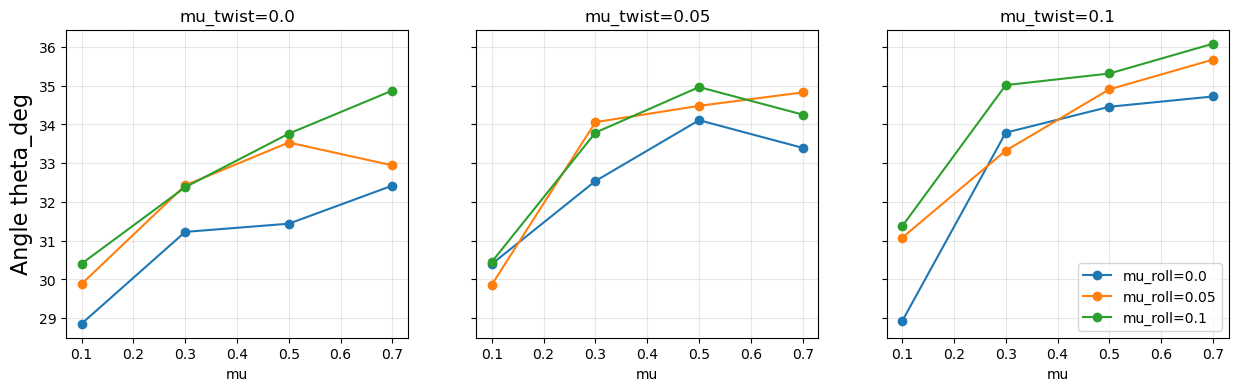

In [18]:
#angle of repose

twist_vals = sorted(df["mu_twist"].unique())
roll_vals = sorted(df["mu_roll"].unique())

fig, axes = plt.subplots(1, len(twist_vals), figsize=(5 * len(twist_vals), 4), sharey=True)

if len(twist_vals) == 1:
    axes = [axes]

for ax, twist_val in zip(axes, twist_vals):
    for roll_val in roll_vals:
        subset = df[
            np.isclose(df["mu_twist"], twist_val) &
            np.isclose(df["mu_roll"], roll_val)
        ].sort_values("mu")

        if len(subset) < 2:
            continue

        ax.plot(subset["mu"], subset["theta_deg"], marker="o", label=f"mu_roll={roll_val}")

    ax.set_xlabel("mu")
    ax.set_title(f"mu_twist={twist_val}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Angle", fontsize=16)
axes[-1].legend()
plt.savefig('Angle.png', dpi=300)
plt.show()

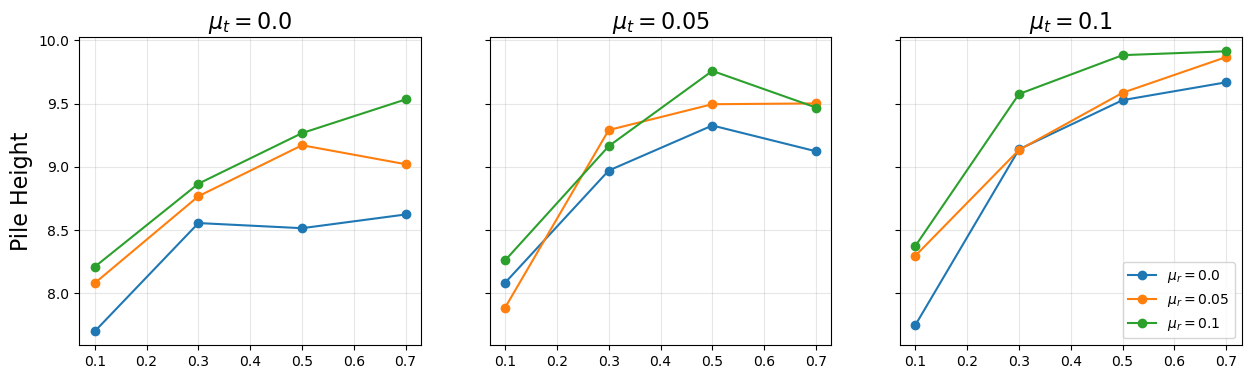

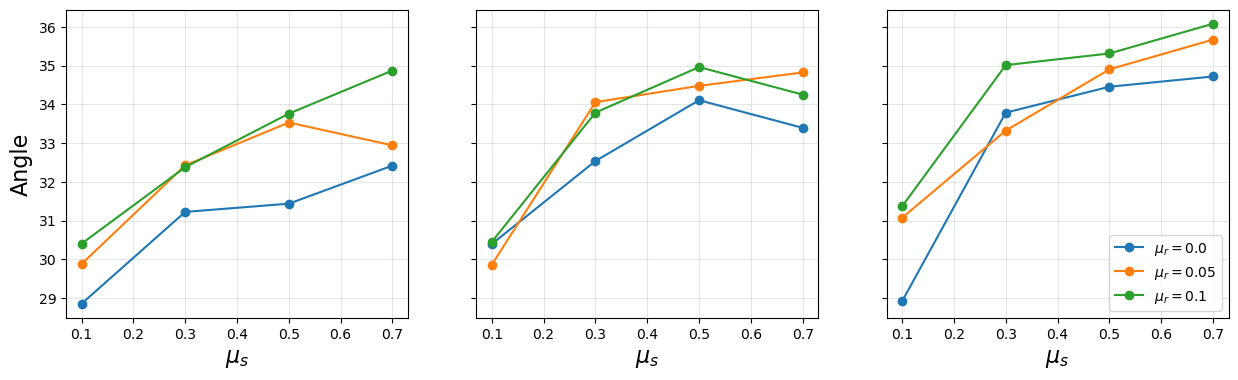

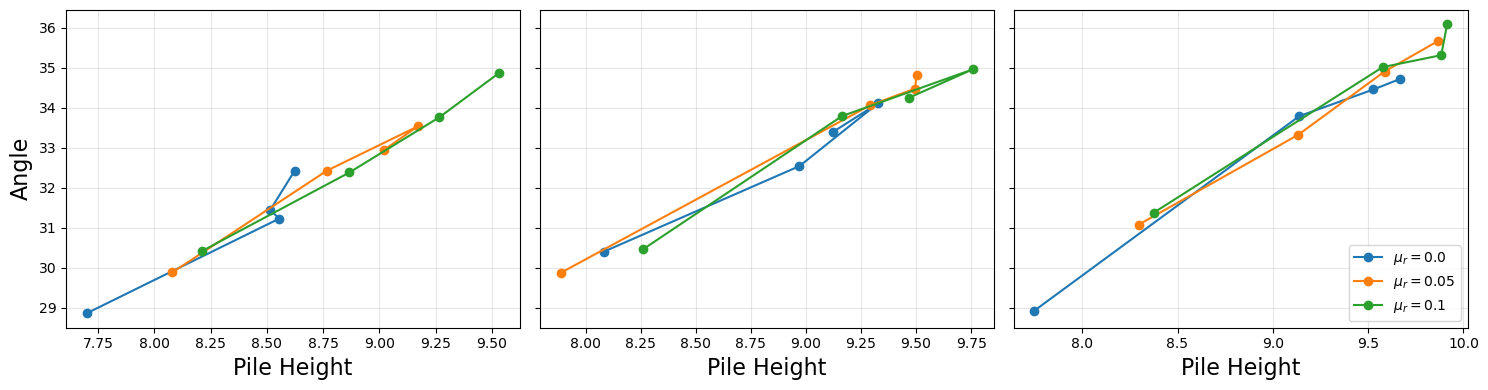

In [89]:
#together
twist_vals = sorted(df["mu_twist"].unique())
roll_vals = sorted(df["mu_roll"].unique())

fig, axes = plt.subplots(1, len(twist_vals), figsize=(5 * len(twist_vals), 4), sharey=True)

if len(twist_vals) == 1:
    axes = [axes]

for ax, twist_val in zip(axes, twist_vals):
    for roll_val in roll_vals:
        subset = df[
            np.isclose(df["mu_twist"], twist_val) &
            np.isclose(df["mu_roll"], roll_val)
        ].sort_values("mu")

        if len(subset) < 2:
            continue

        #ax.plot(subset["mu"], subset["pileH"], marker="o", label=f"mu_roll={roll_val}")
        ax.plot(subset["mu"], subset["pileH"], marker="o", label=r"$\mu_r=$"f"{roll_val}")


    #ax.set_xlabel(r"$\mu$")
    ax.set_title(r"$\mu_t=$"f"{twist_val}", fontsize=16)
    #ax.set_title(f"mu_twist={twist_val}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Pile Height", fontsize=16)
axes[-1].legend()
plt.show()
twist_vals = sorted(df["mu_twist"].unique())
roll_vals = sorted(df["mu_roll"].unique())

fig, axes = plt.subplots(1, len(twist_vals), figsize=(5 * len(twist_vals), 4), sharey=True)

if len(twist_vals) == 1:
    axes = [axes]

for ax, twist_val in zip(axes, twist_vals):
    for roll_val in roll_vals:
        subset = df[
            np.isclose(df["mu_twist"], twist_val) &
            np.isclose(df["mu_roll"], roll_val)
        ].sort_values("mu")

        if len(subset) < 2:
            continue
        #ax.plot(subset["mu"], subset["theta_deg"], marker="o", label=f"mu_roll={roll_val}")
        ax.plot(subset["mu"], subset["theta_deg"], marker="o", label=r"$\mu_r=$"f"{roll_val}")
        ax.plot(fontsize=16)
        #ax.legend(fontsize=14) 

    #ax.set_xlabel("mu")
    ax.set_xlabel(r"$\mu_s$", fontsize=16)
    #ax.set_title(r"$\mu_t=$"f"{twist_val}")
    #ax.set_title(f"mu_twist={twist_val}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Angle", fontsize=16)
axes[-1].legend()

#plt.show()].unique())
roll_vals = sorted(df["mu_roll"].unique())



#angle of repose versus pile height

twist_vals = sorted(df["mu_twist"].unique())
roll_vals = sorted(df["mu_roll"].unique())

fig, axes = plt.subplots(1, len(twist_vals), figsize=(5 * len(twist_vals), 4), sharey=True)

if len(twist_vals) == 1:
    axes = [axes]

for ax, twist_val in zip(axes, twist_vals):
    for roll_val in roll_vals:
        subset = df[
            np.isclose(df["mu_twist"], twist_val) &
            np.isclose(df["mu_roll"], roll_val)
        ].sort_values("mu")

        if len(subset) < 2:
            continue

        #ax.plot(subset["theta_deg"], subset["pileH"], marker="o", label=f"mu_roll={roll_val}")
        #ax.plot(subset["pileH"], subset["theta_deg"], marker="o", label=f"mu_roll={roll_val}")
        ax.plot(subset["pileH"], subset["theta_deg"], marker="o", label=r"$\mu_r=$"f"{roll_val}")
    ax.set_xlabel("Pile Height",fontsize=16)
    #ax.set_title(f"mu_twist={twist_val}")
    ax.grid(True, alpha=0.3)


axes[0].set_ylabel("Angle",fontsize=16)
axes[-1].legend(loc="lower right")
#plt.savefig('AngleVsPileH.png', dpi=300)

plt.tight_layout()

fig.savefig(
    "AngleVsPileH_3panel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



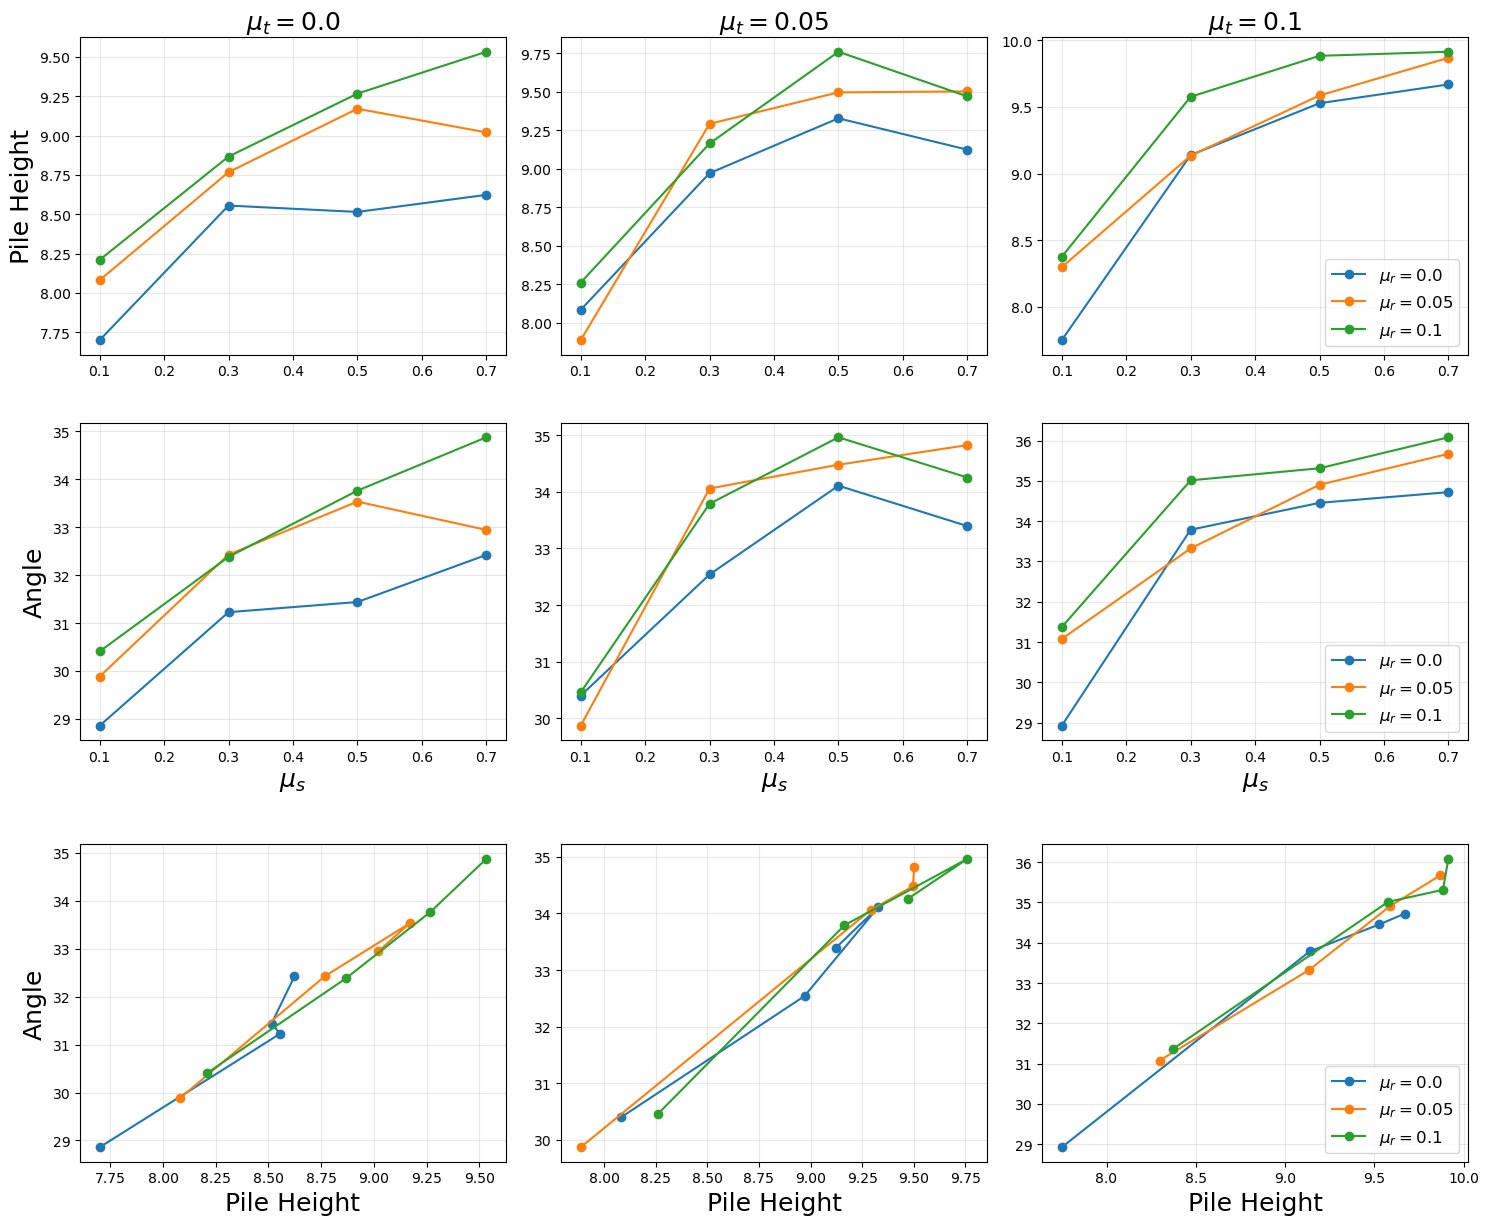

In [99]:
twist_vals = sorted(df["mu_twist"].unique())
roll_vals = sorted(df["mu_roll"].unique())

fig, axes = plt.subplots(
    3, len(twist_vals),
    figsize=(5 * len(twist_vals), 12),
    sharex=False
)

if len(twist_vals) == 1:
    axes = axes.reshape(3, 1)

for col, twist_val in enumerate(twist_vals):

    for roll_val in roll_vals:
        subset = df[
            np.isclose(df["mu_twist"], twist_val) &
            np.isclose(df["mu_roll"], roll_val)
        ].sort_values("mu")
        
        if len(subset) < 2:
            continue

        label = r"$\mu_r=$" f"{roll_val}"

        axes[0, col].plot(subset["mu"], subset["pileH"], marker="o", label=label)
        axes[1, col].plot(subset["mu"], subset["theta_deg"], marker="o", label=label)
        axes[2, col].plot(subset["pileH"], subset["theta_deg"], marker="o", label=label)

    axes[0, col].set_title(r"$\mu_t=$" f"{twist_val}", fontsize=18)

    #axes[0, col].set_xlabel(r"$\mu_s$", fontsize=14)
    axes[1, col].set_xlabel(r"$\mu_s$", fontsize=18)
    axes[2, col].set_xlabel("Pile Height", fontsize=18)
    
    for row in range(3):
        axes[row, col].grid(True, alpha=0.3)
    

axes[0, 0].set_ylabel("Pile Height", fontsize=18)
axes[1, 0].set_ylabel("Angle", fontsize=18)
axes[2, 0].set_ylabel("Angle", fontsize=18)

# Add legends to rightmost column of each row
axes[0, -1].legend(loc="lower right", fontsize=12)
axes[1, -1].legend(loc="lower right", fontsize=12)
axes[2, -1].legend(loc="lower right", fontsize=12)
#separate the bottom row a little
plt.tight_layout()
for ax in axes[2, :]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 - 0.03, pos.width, pos.height])
fig.savefig(
    "All_Height_Angle_Figures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [86]:
print(df)

     mu  mu_roll  mu_twist     pileH  theta_deg      ztot
0   0.1     0.00      0.00  7.699337  28.857291  5.138254
1   0.1     0.00      0.05  8.083253  30.399542  4.781566
2   0.1     0.00      0.10  7.749114  28.922851  4.795804
3   0.1     0.05      0.00  8.080742  29.882307  4.862495
4   0.1     0.05      0.05  7.886472  29.866740  4.754590
5   0.1     0.05      0.10  8.297005  31.075936  4.834020
6   0.1     0.10      0.00  8.209696  30.406949  4.890970
7   0.1     0.10      0.05  8.260068  30.455143  4.795054
8   0.1     0.10      0.10  8.374671  31.371439  4.616710
9   0.3     0.00      0.00  8.555336  31.226669  4.484826
10  0.3     0.00      0.05  8.970818  32.539858  4.207568
11  0.3     0.00      0.10  9.138637  33.788266  4.341701
12  0.3     0.05      0.00  8.767688  32.427300  4.328962
13  0.3     0.05      0.05  9.291204  34.059233  4.263020
14  0.3     0.05      0.10  9.133879  33.324445  4.186587
15  0.3     0.10      0.00  8.866902  32.380103  4.260022
16  0.3     0.

In [20]:
resultmu = df.groupby('mu')['theta_deg'].mean()
resultmur = df.groupby('mu_roll')['theta_deg'].mean()
resultmut = df.groupby('mu_twist')['theta_deg'].mean()
column_average = df['theta_deg'].mean()
print("Total average",column_average)
print("Average by mu",resultmu)
print("Average by mu",resultmur)
print("Average by mu",resultmur)

Total average 32.942888263375124
Average by mu mu
0.1    30.137578
0.3    33.172286
0.5    34.106963
0.7    34.354726
Name: theta_deg, dtype: float64
Average by mu mu_roll
0.00    32.189724
0.05    33.083059
0.10    33.555882
Name: theta_deg, dtype: float64
Average by mu mu_roll
0.00    32.189724
0.05    33.083059
0.10    33.555882
Name: theta_deg, dtype: float64


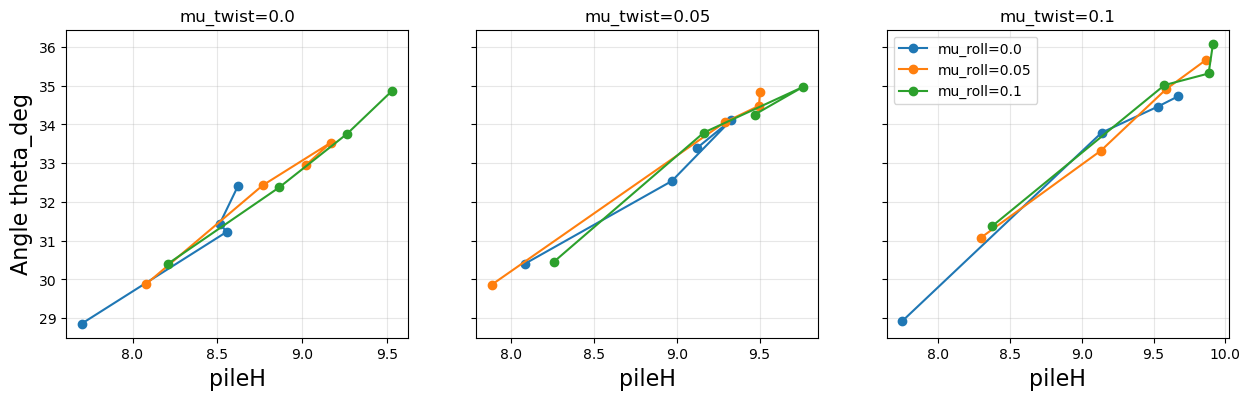

In [21]:
#angle of repose

twist_vals = sorted(df["mu_twist"].unique())
roll_vals = sorted(df["mu_roll"].unique())

fig, axes = plt.subplots(1, len(twist_vals), figsize=(5 * len(twist_vals), 4), sharey=True)

if len(twist_vals) == 1:
    axes = [axes]

for ax, twist_val in zip(axes, twist_vals):
    for roll_val in roll_vals:
        subset = df[
            np.isclose(df["mu_twist"], twist_val) &
            np.isclose(df["mu_roll"], roll_val)
        ].sort_values("mu")

        if len(subset) < 2:
            continue

        #ax.plot(subset["theta_deg"], subset["pileH"], marker="o", label=f"mu_roll={roll_val}")
        ax.plot(subset["pileH"], subset["theta_deg"], marker="o", label=f"mu_roll={roll_val}")

    ax.set_xlabel("pileH",fontsize=16)
    ax.set_title(f"mu_twist={twist_val}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Angle",fontsize=16)
axes[-1].legend()
plt.savefig('AngleVsPileH.png', dpi=300)
plt.show()